# Lab 5: MLOps Services (Feature Store, Experiments, Metadata)

**Date:** February 2026  
**GCP Project:** carty-470812  
**Region:** us-central1  
**Dataset:** Census Income (adult_income)  
**Baseline:** 87.10% accuracy (Lab 2 custom training)  

---

## Overview

Labs 1-4 built a complete ML pipeline, but we used **manual tracking** — DataFrames for experiment results, print statements for metrics, and no centralized feature management. Production ML teams use managed services for:

1. **Reproducibility** — Which hyperparameters produced which results?
2. **Feature sharing** — How do you ensure training and serving use the same features?
3. **Lineage tracking** — Which data was this model trained on?

This lab **retrofits** our existing census pipeline with proper MLOps tooling.

### Three Parts

| Part | Service | What It Replaces |
|------|---------|------------------|
| 1 | Vertex AI Experiments | Manual DataFrame tracking (Lab 3) |
| 2 | Vertex AI Feature Store | Manual feature engineering (Lab 1-2) |
| 3 | Vertex AI Metadata & Lineage | No lineage tracking |

### Cost Warning ⚠️
**Expected cost: $5-10.** Feature Store online serving has hourly costs — delete resources promptly after each section.

---

## Setup

In [13]:
# Install required libraries
!pip install google-cloud-aiplatform google-cloud-bigquery google-cloud-storage pandas scikit-learn MLFlow --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import time
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from google.cloud import aiplatform
from google.cloud import bigquery
from google.cloud import storage

# Project configuration (same as Labs 1-4)
PROJECT_ID = "carty-470812"
REGION = "us-central1"
BUCKET_NAME = f"{PROJECT_ID}-ml-census-data"
BUCKET_URI = f"gs://{BUCKET_NAME}"

# Initialize Vertex AI
aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=BUCKET_URI
)

print(f"Project: {PROJECT_ID}")
print(f"Region: {REGION}")
print(f"Bucket: {BUCKET_URI}")
print(f"Vertex AI SDK version: {aiplatform.__version__}")

Project: carty-470812
Region: us-central1
Bucket: gs://carty-470812-ml-census-data
Vertex AI SDK version: 1.137.0


In [ ]:
# Load the census dataset (same as previous labs)
# Option 1: From GCS (or failback to public)
try:
    df = pd.read_csv(f'gs://{BUCKET_NAME}/data/census_income.csv')
    print(f"Loaded from GCS: {len(df)} rows")
except Exception:
    # Option 2: From BigQuery public dataset
    bq_client = bigquery.Client(project=PROJECT_ID)
    query = "SELECT * FROM `bigquery-public-data.ml_datasets.census_adult_income`"
    df = bq_client.query(query).to_dataframe()
    print(f"Loaded from BigQuery: {len(df)} rows")

print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded from GCS: 32561 rows
Columns: ['age', 'workclass', 'functional_weight', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income_bracket']


,age,workclass,functional_weight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,Private,297847,9th,5,Married-civ-spouse,Other-service,Wife,Black,Female,3411,0,34,United-States,<=50K
1,77,Private,344425,9th,5,Married-civ-spouse,Priv-house-serv,Wife,Black,Female,0,0,10,United-States,<=50K
2,38,Private,131461,9th,5,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,24,Haiti,<=50K


In [4]:
# Preprocessing function (same as previous Labs)
def preprocess_census(df):
    """Standard preprocessing for census data. Returns X, y."""
    data = df.copy()
    
    # Strip whitespace from string columns
    for col in data.select_dtypes(include='object').columns:
        data[col] = data[col].str.strip()
    
    # Target variable
    target_col = 'income_bracket' if 'income_bracket' in data.columns else 'income'
    y = (data[target_col].isin(['>50K', '>50K.'])).astype(int)
    
    # Drop target and any non-feature columns
    drop_cols = [target_col]
    if 'functional_weight' in data.columns:
        drop_cols.append('functional_weight')
    X = data.drop(columns=drop_cols, errors='ignore')
    
    # One-hot encode categoricals
    X = pd.get_dummies(X, drop_first=True)
    
    return X, y

X, y = preprocess_census(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target distribution: {y.value_counts(normalize=True).to_dict()}")

Train: (26048, 99), Test: (6513, 99)
Target distribution: {0: 0.7591904425539756, 1: 0.2408095574460244}


---

# Part 1: Vertex AI Experiments

## Why This Matters

In Lab 3, we tracked hyperparameter tuning results in a pandas DataFrame. That works for one person doing one experiment, but it breaks down when:

- **Multiple people** are running experiments on the same model
- You want to **compare results across days/weeks** without re-running notebooks
- You need **audit trails** ("which model is in production and what produced it?")
- You want to **link experiments to deployed models** (lineage)

Vertex AI Experiments is a managed service that solves all of these. Think of it as a **centralized lab notebook** that lives in the cloud, not in your local Jupyter session.

### Key Concepts

- **Experiment**: A logical group (like "census-tuning")
- **Run**: A single training attempt within an experiment
- **Parameters**: Inputs you control (learning_rate, n_estimators, etc.)
- **Metrics**: Outputs you measure (accuracy, ROC AUC, training time)

---

### Step 1.1: Create an Experiment and Log Your Lab 2 Baseline

In [5]:
# Create the experiment
EXPERIMENT_NAME = 'census-mlops-lab5'

aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    experiment=EXPERIMENT_NAME
)

print(f"Experiment '{EXPERIMENT_NAME}' initialized")
print(f"View in console: https://console.cloud.google.com/vertex-ai/experiments?project={PROJECT_ID}")

Creating Tensorboard
Create Tensorboard backing LRO: projects/873708835509/locations/us-central1/tensorboards/1689098349891813376/operations/2121521713156980736
Tensorboard created. Resource name: projects/873708835509/locations/us-central1/tensorboards/1689098349891813376
To use this Tensorboard in another session:
tb = aiplatform.Tensorboard('projects/873708835509/locations/us-central1/tensorboards/1689098349891813376')


Experiment 'census-mlops-lab5' initialized
View in console: https://console.cloud.google.com/vertex-ai/experiments?project=carty-470812


In [6]:
# Run 1: Log the Lab 2 baseline (reproduce it here so we have a tracked record)
with aiplatform.start_run('lab2-baseline') as run:
    # Log the parameters we used in Lab 2
    run.log_params({
        'algorithm': 'GradientBoostingClassifier',
        'n_estimators': 100,
        'max_depth': 5,
        'learning_rate': 0.1,
        'min_samples_split': 2,
        'data_source': 'census_income_csv',
        'test_size': 0.2,
    })
    
    # Train the model (same as Lab 2)
    start_time = time.time()
    model_baseline = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        min_samples_split=2,
        random_state=42
    )
    model_baseline.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Evaluate
    y_pred = model_baseline.predict(X_test)
    y_prob = model_baseline.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    
    # Log metrics
    run.log_metrics({
        'accuracy': round(accuracy, 4),
        'roc_auc': round(roc_auc, 4),
        'f1_score': round(f1, 4),
        'training_time_sec': round(training_time, 2),
    })
    
    print(f"Lab 2 Baseline logged:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC AUC:  {roc_auc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Training: {training_time:.2f}s")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-lab2-baseline to Experiment: census-mlops-lab5


Lab 2 Baseline logged:
  Accuracy: 0.8721
  ROC AUC:  0.9293
  F1 Score: 0.7078
  Training: 4.53s


### Step 1.2: Run Multiple Experiments with Different Configurations

Now let's do what we did in Lab 3 manually — but this time everything gets tracked automatically.

In [7]:
# Define experiment configurations
# These are the same kinds of variations we explored in Lab 3
experiments = [
    {
        'run_name': 'more-trees',
        'params': {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2}
    },
    {
        'run_name': 'deeper-trees',
        'params': {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'min_samples_split': 2}
    },
    {
        'run_name': 'slow-learner',
        'params': {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'min_samples_split': 2}
    },
    {
        'run_name': 'regularized',
        'params': {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.1, 'min_samples_split': 5}
    },
    {
        'run_name': 'aggressive',
        'params': {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'min_samples_split': 2}
    },
]

print(f"Running {len(experiments)} experiments...")
print("=" * 70)

Running 5 experiments...


In [8]:
# Run all experiments, logging to Vertex AI
for exp in experiments:
    with aiplatform.start_run(exp['run_name']) as run:
        # Log parameters
        run.log_params({
            'algorithm': 'GradientBoostingClassifier',
            **exp['params'],
            'data_source': 'census_income_csv',
            'test_size': 0.2,
        })
        
        # Train
        start_time = time.time()
        model = GradientBoostingClassifier(
            **exp['params'],
            random_state=42
        )
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Evaluate
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)
        
        # Log metrics
        run.log_metrics({
            'accuracy': round(accuracy, 4),
            'roc_auc': round(roc_auc, 4),
            'f1_score': round(f1, 4),
            'training_time_sec': round(training_time, 2),
        })
        
        print(f"  {exp['run_name']:20s} | Acc: {accuracy:.4f} | AUC: {roc_auc:.4f} | F1: {f1:.4f} | Time: {training_time:.1f}s")

print("\n" + "=" * 70)
print("All experiments logged to Vertex AI!")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-more-trees to Experiment: census-mlops-lab5


  more-trees           | Acc: 0.8727 | AUC: 0.9307 | F1: 0.7117 | Time: 9.0s
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-deeper-trees to Experiment: census-mlops-lab5


  deeper-trees         | Acc: 0.8701 | AUC: 0.9272 | F1: 0.7081 | Time: 9.1s
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-slow-learner to Experiment: census-mlops-lab5


  slow-learner         | Acc: 0.8723 | AUC: 0.9295 | F1: 0.7058 | Time: 9.0s
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-regularized to Experiment: census-mlops-lab5


  regularized          | Acc: 0.8739 | AUC: 0.9306 | F1: 0.7154 | Time: 9.3s
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-aggressive to Experiment: census-mlops-lab5


  aggressive           | Acc: 0.8707 | AUC: 0.9263 | F1: 0.7105 | Time: 27.5s

All experiments logged to Vertex AI!


### Step 1.3: Retrieve and Compare Runs Using the SDK

This is the payoff — instead of maintaining your own DataFrame, Vertex AI stores everything and gives you a clean comparison.

In [9]:
# Get all experiment results as a DataFrame
experiment_df = aiplatform.get_experiment_df(EXPERIMENT_NAME)

print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Total runs: {len(experiment_df)}")
print(f"\nColumns available: {list(experiment_df.columns)}")
experiment_df

Experiment: census-mlops-lab5
Total runs: 6

Columns available: ['experiment_name', 'run_name', 'run_type', 'state', 'param.min_samples_split', 'param.max_depth', 'param.data_source', 'param.learning_rate', 'param.n_estimators', 'param.test_size', 'param.algorithm', 'metric.roc_auc', 'metric.accuracy', 'metric.training_time_sec', 'metric.f1_score']


,experiment_name,run_name,run_type,state,param.min_samples_split,param.max_depth,param.data_source,param.learning_rate,param.n_estimators,param.test_size,param.algorithm,metric.roc_auc,metric.accuracy,metric.training_time_sec,metric.f1_score
0,census-mlops-lab5,aggressive,system.ExperimentRun,COMPLETE,2.0,10.0,census_income_csv,0.05,300.0,0.2,GradientBoostingClassifier,0.9263,0.8707,27.50,0.7105
1,census-mlops-lab5,regularized,system.ExperimentRun,COMPLETE,5.0,7.0,census_income_csv,0.10,150.0,0.2,GradientBoostingClassifier,0.9306,0.8739,9.26,0.7154
2,census-mlops-lab5,slow-learner,system.ExperimentRun,COMPLETE,2.0,5.0,census_income_csv,0.05,200.0,0.2,GradientBoostingClassifier,0.9295,0.8723,8.95,0.7058
3,census-mlops-lab5,deeper-trees,system.ExperimentRun,COMPLETE,2.0,10.0,census_income_csv,0.10,100.0,0.2,GradientBoostingClassifier,0.9272,0.8701,9.10,0.7081
4,census-mlops-lab5,more-trees,system.ExperimentRun,COMPLETE,2.0,5.0,census_income_csv,0.10,200.0,0.2,GradientBoostingClassifier,0.9307,0.8727,9.00,0.7117
5,census-mlops-lab5,lab2-baseline,system.ExperimentRun,COMPLETE,2.0,5.0,census_income_csv,0.10,100.0,0.2,GradientBoostingClassifier,0.9293,0.8721,4.53,0.7078


In [10]:
# Clean up the DataFrame for a nice comparison view
# Vertex AI prefixes metric columns with 'metric.' and param columns with 'param.'
metric_cols = [c for c in experiment_df.columns if c.startswith('metric.')]
param_cols = [c for c in experiment_df.columns if c.startswith('param.')]

# Sort by accuracy (descending)
comparison = experiment_df[['run_name'] + metric_cols + param_cols].copy()
if 'metric.accuracy' in comparison.columns:
    comparison = comparison.sort_values('metric.accuracy', ascending=False)

print("EXPERIMENT COMPARISON (sorted by accuracy)")
print("=" * 80)
comparison

EXPERIMENT COMPARISON (sorted by accuracy)


,run_name,metric.roc_auc,metric.accuracy,metric.training_time_sec,metric.f1_score,param.min_samples_split,param.max_depth,param.data_source,param.learning_rate,param.n_estimators,param.test_size,param.algorithm
1,regularized,0.9306,0.8739,9.26,0.7154,5.0,7.0,census_income_csv,0.10,150.0,0.2,GradientBoostingClassifier
4,more-trees,0.9307,0.8727,9.00,0.7117,2.0,5.0,census_income_csv,0.10,200.0,0.2,GradientBoostingClassifier
2,slow-learner,0.9295,0.8723,8.95,0.7058,2.0,5.0,census_income_csv,0.05,200.0,0.2,GradientBoostingClassifier
5,lab2-baseline,0.9293,0.8721,4.53,0.7078,2.0,5.0,census_income_csv,0.10,100.0,0.2,GradientBoostingClassifier
0,aggressive,0.9263,0.8707,27.50,0.7105,2.0,10.0,census_income_csv,0.05,300.0,0.2,GradientBoostingClassifier
3,deeper-trees,0.9272,0.8701,9.10,0.7081,2.0,10.0,census_income_csv,0.10,100.0,0.2,GradientBoostingClassifier


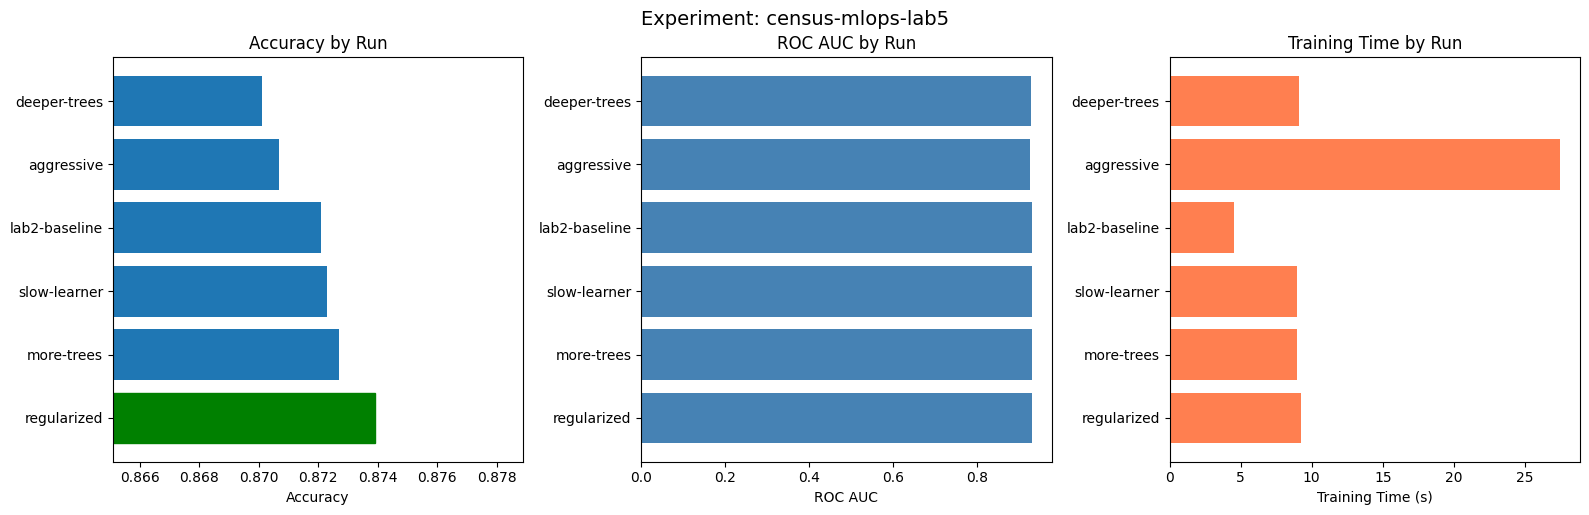

In [11]:
# Visualize the results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy comparison
if 'metric.accuracy' in comparison.columns:
    ax = axes[0]
    bars = ax.barh(comparison['run_name'], comparison['metric.accuracy'])
    ax.set_xlabel('Accuracy')
    ax.set_title('Accuracy by Run')
    ax.set_xlim(comparison['metric.accuracy'].min() - 0.005, 
                comparison['metric.accuracy'].max() + 0.005)
    # Highlight the best run
    best_idx = comparison['metric.accuracy'].idxmax()
    for i, bar in enumerate(bars):
        if comparison.index[i] == best_idx:
            bar.set_color('green')

# ROC AUC comparison
if 'metric.roc_auc' in comparison.columns:
    ax = axes[1]
    ax.barh(comparison['run_name'], comparison['metric.roc_auc'], color='steelblue')
    ax.set_xlabel('ROC AUC')
    ax.set_title('ROC AUC by Run')

# Training time comparison
if 'metric.training_time_sec' in comparison.columns:
    ax = axes[2]
    ax.barh(comparison['run_name'], comparison['metric.training_time_sec'], color='coral')
    ax.set_xlabel('Training Time (s)')
    ax.set_title('Training Time by Run')

plt.tight_layout()
plt.suptitle(f'Experiment: {EXPERIMENT_NAME}', y=1.02, fontsize=14)
plt.show()

### Step 1.4: Autologging (Bonus)

Vertex AI can also **automatically** log scikit-learn parameters and metrics — no manual `log_params()` needed. This is useful when you don't want to track every detail manually.

In [14]:
# Enable autologging for scikit-learn
aiplatform.autolog()

# Just train a model — Vertex AI SDK captures everything automatically
aiplatform.start_run('autolog-demo')

model_auto = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.08,
    random_state=42
)
model_auto.fit(X_train, y_train)

# Score it (autologging captures this too)
score = model_auto.score(X_test, y_test)
print(f"Autologged model accuracy: {score:.4f}")

aiplatform.end_run()

# Disable autologging when done
aiplatform.autolog(disable=True)

print("\nCheck the experiment in the console — autologging captured params automatically!")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/census-mlops-lab5-autolog-demo to Experiment: census-mlops-lab5


Autologged model accuracy: 0.8733

Check the experiment in the console — autologging captured params automatically!


In [15]:
# Refresh the experiment DataFrame to see the autologged run
experiment_df = aiplatform.get_experiment_df(EXPERIMENT_NAME)
print(f"Total runs now: {len(experiment_df)}")
print(f"\nRun names: {list(experiment_df['run_name'])}")
experiment_df[['run_name'] + [c for c in experiment_df.columns if c.startswith('metric.')]]

Total runs now: 7

Run names: ['autolog-demo', 'aggressive', 'regularized', 'slow-learner', 'deeper-trees', 'more-trees', 'lab2-baseline']


,run_name,metric.roc_auc,metric.training_time_sec,metric.accuracy,metric.f1_score
0,autolog-demo,NaN,NaN,NaN,NaN
1,aggressive,0.9263,27.50,0.8707,0.7105
2,regularized,0.9306,9.26,0.8739,0.7154
3,slow-learner,0.9295,8.95,0.8723,0.7058
4,deeper-trees,0.9272,9.10,0.8701,0.7081
5,more-trees,0.9307,9.00,0.8727,0.7117
6,lab2-baseline,0.9293,4.53,0.8721,0.7078


### Part 1 Checkpoint ✅

**What we did:**
- Created a Vertex AI Experiment
- Logged 6 training runs with parameters and metrics
- Retrieved and compared results using `get_experiment_df()`
- Tried autologging for zero-effort tracking

**What this replaces:**
- The manual DataFrame tracking from Lab 3
- The print statements scattered across notebooks

**Exam concepts:**
- `aiplatform.init(experiment=...)` creates/connects to an experiment
- `aiplatform.start_run()` / `end_run()` define a run
- `log_params()` for inputs, `log_metrics()` for outputs
- `get_experiment_df()` retrieves all runs as a DataFrame
- `autolog()` for framework-native automatic tracking
- Experiments integrate with Vertex AI Metadata for lineage (Part 3)

**When to use Experiments vs. manual tracking:**
- Solo, quick prototype → manual DataFrame is fine
- Team collaboration, production models, audit requirements → Vertex AI Experiments
- The exam will almost always point to the managed service

---

# Part 2: Vertex AI Feature Store

## Why This Matters

You already know about **train-serve skew** from Lab 1 (the TRANSFORM pattern in BigQuery ML). Feature Store solves the same problem at a **broader scale**:

- **TRANSFORM (Lab 1)**: Bundles feature engineering with ONE model. Great for single-model, SQL-based pipelines.
- **Feature Store**: Centralizes features for MANY models and teams. Features are computed once, stored, and served consistently for both training (offline) and prediction (online).

### Architecture

```
BigQuery Table (source of truth)
    │
    ├── Feature Group (logical grouping of features)
    │       ├── Feature: age_group
    │       ├── Feature: hours_ratio  
    │       └── Feature: education_num
    │
    └── Feature Online Store (serving layer)
            └── Feature View (what to serve)
                    ↓
              Online Predictions (low latency)
```

### Key Concepts
- **Feature Group**: Logical grouping tied to a BigQuery source
- **Feature**: Individual column within a Feature Group
- **Feature Online Store**: Serving infrastructure (Bigtable or Optimized)
- **Feature View**: Defines which features to serve from which groups

---

### Step 2.1: Prepare Feature Data in BigQuery

Feature Store reads from BigQuery, so first we need to create a feature table with engineered features and an entity ID column.

In [19]:
# Load census data from your GCS bucket into BigQuery
# (since we can't access the public dataset directly)

DATASET_ID = 'census_features'
TABLE_ID = f'{PROJECT_ID}.{DATASET_ID}.census_feature_table'
RAW_TABLE_ID = f'{PROJECT_ID}.{DATASET_ID}.census_raw'

# Create dataset
dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
dataset_ref.location = REGION
bq_client.create_dataset(dataset_ref, exists_ok=True)

# Load CSV from GCS into a raw table
job_config = bigquery.LoadJobConfig(
    autodetect=True,
    source_format=bigquery.SourceFormat.CSV,
    skip_leading_rows=1,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

load_job = bq_client.load_table_from_uri(
    f'gs://{BUCKET_NAME}/data/census_income.csv',
    RAW_TABLE_ID,
    job_config=job_config,
)
load_job.result()

row_count = bq_client.get_table(RAW_TABLE_ID).num_rows
print(f"Loaded {row_count} rows into {RAW_TABLE_ID}")

Loaded 32561 rows into carty-470812.census_features.census_raw


In [20]:
# Create engineered feature table from our raw data
feature_query = f"""
CREATE OR REPLACE TABLE `{TABLE_ID}` AS
SELECT
    GENERATE_UUID() AS entity_id,
    
    age,
    education_num,
    hours_per_week,
    capital_gain,
    capital_loss,
    
    CASE 
        WHEN age < 25 THEN 'young'
        WHEN age < 45 THEN 'mid'
        WHEN age < 65 THEN 'senior'
        ELSE 'retired'
    END AS age_group,
    
    ROUND(hours_per_week / 40.0, 2) AS hours_ratio,
    
    CASE WHEN capital_gain > 0 THEN 1 ELSE 0 END AS has_capital_gain,
    CASE WHEN capital_loss > 0 THEN 1 ELSE 0 END AS has_capital_loss,
    
    CASE
        WHEN education_num >= 13 THEN 'advanced'
        WHEN education_num >= 9 THEN 'standard'
        ELSE 'basic'
    END AS education_level,
    
    CURRENT_TIMESTAMP() AS feature_timestamp
    
FROM `{RAW_TABLE_ID}`
"""

bq_client.query(feature_query).result()
print(f"Feature table created: {TABLE_ID}")

# Verify
verify = bq_client.query(f"SELECT COUNT(*) as cnt FROM `{TABLE_ID}`").to_dataframe()
print(f"Rows: {verify['cnt'].iloc[0]}")

preview = bq_client.query(f"SELECT * FROM `{TABLE_ID}` LIMIT 5").to_dataframe()
preview

Feature table created: carty-470812.census_features.census_feature_table


/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Rows: 32561


,entity_id,age,education_num,hours_per_week,capital_gain,capital_loss,age_group,hours_ratio,has_capital_gain,has_capital_loss,education_level,feature_timestamp
0,56bcec57-bc85-42b3-acd9-5334cbf2dbe5,17,6,4,0,0,young,0.10,0,0,basic,2026-02-22 07:54:22.012386+00:00
1,008ae1c8-5ecc-4a4b-b98e-6534aed77656,17,6,4,0,0,young,0.10,0,0,basic,2026-02-22 07:54:22.012386+00:00
2,723c44bd-2f44-48d3-af41-186173db7161,17,6,5,0,0,young,0.13,0,0,basic,2026-02-22 07:54:22.012386+00:00
3,f2859898-8037-41c6-9408-a63d4dbb9bf0,17,7,5,0,0,young,0.13,0,0,basic,2026-02-22 07:54:22.012386+00:00
4,17795b71-0cd6-4562-8a49-11ca2aa2c78a,17,7,5,0,0,young,0.13,0,0,basic,2026-02-22 07:54:22.012386+00:00


### Step 2.2: Create a Feature Group

A Feature Group connects to the BigQuery table and registers features for the Feature Store.

In [21]:
from vertexai.resources.preview import feature_store

# Create feature group linked to our BigQuery table
FEATURE_GROUP_ID = 'census_features'

try:
    census_fg = feature_store.FeatureGroup.create(
        name=FEATURE_GROUP_ID,
        source=feature_store.utils.FeatureGroupBigQuerySource(
            uri=f'bq://{TABLE_ID}',
            entity_id_columns=['entity_id'],
        ),
    )
    print(f"Feature Group created: {FEATURE_GROUP_ID}")
    print(f"  Source: bq://{TABLE_ID}")
except Exception as e:
    print(f"Error (may already exist): {e}")
    # If it exists, get a reference to it
    census_fg = feature_store.FeatureGroup(FEATURE_GROUP_ID)

Creating FeatureGroup
Create FeatureGroup backing LRO: projects/873708835509/locations/us-central1/featureGroups/census_features/operations/3619179695490203648
FeatureGroup created. Resource name: projects/873708835509/locations/us-central1/featureGroups/census_features
To use this FeatureGroup in another session:
feature_group = aiplatform.FeatureGroup('projects/873708835509/locations/us-central1/featureGroups/census_features')
Feature Group created: census_features
  Source: bq://carty-470812.census_features.census_feature_table


In [22]:
# Register individual features within the group
feature_names = [
    'age',
    'education_num',
    'hours_per_week',
    'age_group',
    'hours_ratio',
    'has_capital_gain',
    'has_capital_loss',
    'education_level',
]

for fname in feature_names:
    try:
        census_fg.create_feature(fname)
        print(f"  ✅ Registered feature: {fname}")
    except Exception as e:
        print(f"  ⚠️  Feature '{fname}': {e}")

print(f"\nFeature Group '{FEATURE_GROUP_ID}' has {len(feature_names)} features registered")

Creating Feature
Create Feature backing LRO: projects/873708835509/locations/us-central1/featureGroups/census_features/features/age/operations/2592358980449730560
Feature created. Resource name: projects/873708835509/locations/us-central1/featureGroups/census_features/features/age
To use this Feature in another session:
feature = aiplatform.Feature('projects/873708835509/locations/us-central1/featureGroups/census_features/features/age')
  ✅ Registered feature: age
Creating Feature
Create Feature backing LRO: projects/873708835509/locations/us-central1/featureGroups/census_features/features/education_num/operations/301574882490056704
Feature created. Resource name: projects/873708835509/locations/us-central1/featureGroups/census_features/features/education_num
To use this Feature in another session:
feature = aiplatform.Feature('projects/873708835509/locations/us-central1/featureGroups/census_features/features/education_num')
  ✅ Registered feature: education_num
Creating Feature
Create

### Step 2.3: Create an Online Store and Feature View

The Online Store is the serving infrastructure. A Feature View defines which features from which groups to serve.

⚠️ **Cost note:** Online stores have hourly costs. We'll delete it at the end of this section.

In [24]:
# Create an online store (Bigtable-backed)
ONLINE_STORE_ID = 'census_online_store'

try:
    online_store = feature_store.FeatureOnlineStore.create_bigtable_store(
        name=ONLINE_STORE_ID,
        min_node_count=1,
        max_node_count=1,  # Keep minimal for lab
    )
    print(f"Online Store created: {ONLINE_STORE_ID}")
    print(f"  Type: Bigtable")
    print(f"  Nodes: 1 (minimum for cost control)")
    print(f"\n⚠️  REMEMBER: Delete this when done to avoid ongoing charges!")
except Exception as e:
    print(f"Error (may already exist): {e}")
    online_store = feature_store.FeatureOnlineStore(ONLINE_STORE_ID)

Creating FeatureOnlineStore
Create FeatureOnlineStore backing LRO: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/operations/4548610068588789760
FeatureOnlineStore created. Resource name: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store
To use this FeatureOnlineStore in another session:
feature_online_store = aiplatform.FeatureOnlineStore('projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store')
Online Store created: census_online_store
  Type: Bigtable
  Nodes: 1 (minimum for cost control)

⚠️  REMEMBER: Delete this when done to avoid ongoing charges!


In [26]:
# Wait for the online store to be ready (can take a few minutes)
print(f"https://console.cloud.google.com/vertex-ai/feature-store/online-stores?project={PROJECT_ID}")


https://console.cloud.google.com/vertex-ai/feature-store/online-stores?project=carty-470812


In [28]:
# Create a Feature View that connects the Feature Group to the Online Store
FEATURE_VIEW_ID = 'census_features_view'

try:
    census_fv = online_store.create_feature_view(
        name=FEATURE_VIEW_ID,
        source=feature_store.utils.FeatureViewBigQuerySource(
            uri=f'bq://{TABLE_ID}',
            entity_id_columns=['entity_id'],
        ),
        # Sync schedule — for production you'd set a cron schedule
        # For the lab, we'll trigger a manual sync
    )
    print(f"Feature View created: {FEATURE_VIEW_ID}")
    print(f"  Source: {TABLE_ID}")
    print(f"  Online Store: {ONLINE_STORE_ID}")
except Exception as e:
    print(f"Error: {e}")

Creating FeatureView
Create FeatureView backing LRO: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view/operations/4625171262254088192
FeatureView created. Resource name: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view
To use this FeatureView in another session:
feature_view = aiplatform.FeatureView('projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view')
Feature View created: census_features_view
  Source: carty-470812.census_features.census_feature_table
  Online Store: census_online_store


In [44]:
# Trigger a new manual sync (if you need to refresh after data changes)
census_fv.sync()
print("Manual sync triggered")

# Check sync status using the service client
from google.cloud import aiplatform_v1

client = aiplatform_v1.FeatureOnlineStoreAdminServiceClient(
    client_options={"api_endpoint": f"{REGION}-aiplatform.googleapis.com"}
)

feature_view_path = (
    f"projects/{PROJECT_ID}/locations/{REGION}"
    f"/featureOnlineStores/{ONLINE_STORE_ID}"
    f"/featureViews/{FEATURE_VIEW_ID}"
)

syncs = client.list_feature_view_syncs(parent=feature_view_path)
for sync in syncs:
    print(f"Sync: {sync.name}")
    print(f"  Status: {sync.final_status}")
    print(f"  Row synced: {sync.sync_summary.row_synced if sync.sync_summary else 'N/A'}")

Manual sync triggered
Sync: projects/carty-470812/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view/featureViewSyncs/3039204805240160256
  Status: 
  Row synced: N/A
Sync: projects/carty-470812/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view/featureViewSyncs/8376462944883441664
  Status: 
  Row synced: N/A


### Step 2.4: Serve Features Online

Once the sync is complete, we can fetch features by entity ID. This is how a prediction service would look up features at serving time.

In [45]:
# First, get some entity IDs to look up
entity_query = f"SELECT entity_id FROM `{TABLE_ID}` LIMIT 5"
entity_ids = bq_client.query(entity_query).to_dataframe()
print("Sample entity IDs:")
print(entity_ids)

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Sample entity IDs:
                              entity_id
0  56bcec57-bc85-42b3-acd9-5334cbf2dbe5
1  008ae1c8-5ecc-4a4b-b98e-6534aed77656
2  723c44bd-2f44-48d3-af41-186173db7161
3  f2859898-8037-41c6-9408-a63d4dbb9bf0
4  17795b71-0cd6-4562-8a49-11ca2aa2c78a


In [46]:
# Fetch features online for a specific entity
# This simulates what a production serving system would do
from google.cloud.aiplatform_v1 import FeatureOnlineStoreServiceClient
from google.cloud.aiplatform_v1.types import feature_online_store_service as fos_types

# Create the client
data_client = FeatureOnlineStoreServiceClient(
    client_options={"api_endpoint": f"{REGION}-aiplatform.googleapis.com"}
)

# Fetch features for the first entity
test_entity_id = entity_ids['entity_id'].iloc[0]
print(f"Fetching features for entity: {test_entity_id}")

try:
    response = data_client.fetch_feature_values(
        request=fos_types.FetchFeatureValuesRequest(
            feature_view=(
                f"projects/{PROJECT_ID}/locations/{REGION}"
                f"/featureOnlineStores/{ONLINE_STORE_ID}"
                f"/featureViews/{FEATURE_VIEW_ID}"
            ),
            data_key=fos_types.FeatureViewDataKey(key=test_entity_id),
        )
    )
    print(f"\nFeature values returned:")
    for feature in response.key_values.features:
        print(f"  {feature.name}: {feature.value}")
except Exception as e:
    print(f"Online serving error: {e}")
    print("\nThis usually means the sync hasn't completed yet.")
    print("Wait a few minutes and retry, or check the console.")

Fetching features for entity: 56bcec57-bc85-42b3-acd9-5334cbf2dbe5

Feature values returned:
  age: int64_value: 17

  education_num: int64_value: 6

  hours_per_week: int64_value: 4

  capital_gain: int64_value: 0

  capital_loss: int64_value: 0

  age_group: string_value: "young"

  hours_ratio: double_value: 0.1

  has_capital_gain: int64_value: 0

  has_capital_loss: int64_value: 0

  education_level: string_value: "basic"

  feature_timestamp: int64_value: 1771746862012386



### Step 2.5: Offline Feature Serving (for Training)

For training, you don't need low-latency online serving. You read features directly from BigQuery (the offline store).

In [47]:
# Offline serving: Read features from the BigQuery source for training
# This is how you'd use Feature Store features for batch training

offline_query = f"""
SELECT 
    age,
    education_num,
    hours_per_week,
    age_group,
    hours_ratio,
    has_capital_gain,
    has_capital_loss,
    education_level
FROM `{TABLE_ID}`
LIMIT 10
"""

offline_features = bq_client.query(offline_query).to_dataframe()
print("Offline feature serving (for training):")
print(f"Same data as online, but read directly from BigQuery.")
print(f"No latency requirements — just query the table.\n")
offline_features

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Offline feature serving (for training):
Same data as online, but read directly from BigQuery.
No latency requirements — just query the table.



,age,education_num,hours_per_week,age_group,hours_ratio,has_capital_gain,has_capital_loss,education_level
0,17,6,4,young,0.10,0,0,basic
1,17,6,4,young,0.10,0,0,basic
2,17,6,5,young,0.13,0,0,basic
3,17,7,5,young,0.13,0,0,basic
4,17,7,5,young,0.13,0,0,basic
5,17,7,5,young,0.13,0,0,basic
6,17,7,5,young,0.13,0,0,basic
7,17,6,5,young,0.13,0,0,basic
8,17,8,6,young,0.15,0,0,basic
9,17,6,6,young,0.15,0,0,basic


### Step 2.6: Feature Store Decision Framework

This is exam-critical. Know when to use which approach:

| Approach | When to Use | Example |
|----------|------------|----------|
| **TRANSFORM (BigQuery ML)** | Single model, SQL-based features | Lab 1: Census model in BigQuery ML |
| **Manual in training script** | Single data scientist, simple features | Lab 2: `pd.get_dummies()` in `train.py` |
| **Feature Store** | Multiple models/teams sharing features, online serving needed | This lab: Centralized features for census + other models |
| **Feature Store + Online Store** | Real-time predictions needing feature lookup | E-commerce: Look up user features at prediction time |

**Exam pattern:** If the question mentions "multiple teams sharing features" or "consistent features across training and serving at scale" → Feature Store.

In [ ]:
# ⚠️ CLEANUP: Delete the online store to stop ongoing charges
# The online store has hourly costs — always delete when done!

print("⚠️  IMPORTANT: Delete Feature Store resources to avoid charges")
print("")
print("Run these commands to clean up:")
print(f"")
print("Option 1: Via the console")
print(f"  https://console.cloud.google.com/vertex-ai/feature-store/online-stores?project={PROJECT_ID}")
print(f"  Delete the online store '{ONLINE_STORE_ID}' (and its feature views)")
print("")
print("Option 2: Via code (uncomment and run):")

In [48]:
# Uncomment the lines below to delete Feature Store resources
# Delete in order: Feature View → Online Store → Feature Group

census_fv.delete()
print("Feature View deleted")

online_store.delete(force=True)
print("Online Store deleted")

census_fg.delete(force=True)
print("Feature Group deleted")

print("\n✅ All Feature Store resources cleaned up!")

Deleting FeatureView resource: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view
Delete FeatureView backing LRO: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/operations/549747851018633216
FeatureView resource projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store/featureViews/census_features_view deleted.
Feature View deleted
Deleting FeatureOnlineStore resource: projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store
Delete FeatureOnlineStore backing LRO: projects/873708835509/locations/us-central1/operations/3609943797816885248
FeatureOnlineStore resource projects/873708835509/locations/us-central1/featureOnlineStores/census_online_store deleted.
Online Store deleted
Deleting FeatureGroup resource: projects/873708835509/locations/us-central1/featureGroups/census_features
Delete FeatureGroup backing LRO: projects/8737088355

### Part 2 Checkpoint ✅

**What we did:**
- Created a BigQuery table with engineered features (entity_id + features + timestamp)
- Registered a Feature Group pointing to that table
- Created individual Feature registrations
- Set up an Online Store (Bigtable) for low-latency serving
- Created a Feature View to sync features to the online store
- Fetched features online (simulating prediction-time lookup)
- Queried features offline (for batch training)

**Key takeaways:**
- Feature Store = **centralized feature management** at scale
- **Online Store** = low-latency serving (Bigtable/Optimized) — has ongoing costs
- **Offline Store** = BigQuery itself — for training, no extra cost
- Feature Groups register BigQuery tables as feature sources
- Feature Views define what to serve from which sources
- Always clean up online stores when not in use!

**Connection to previous labs:**
- Lab 1's TRANSFORM pattern prevents skew for a single model
- Feature Store prevents skew across multiple models and teams
- Same principle, different scale

---

# Part 3: Vertex AI Metadata & ML Lineage

## Why This Matters

In production ML, you need to answer questions like:
- "Which data was this model trained on?"
- "What hyperparameters produced the model that's currently serving?"
- "If we retrain with new data, can we reproduce the old model?"
- "For compliance, can we trace this prediction back to its training data?"

Vertex AI Metadata tracks this automatically when you use Vertex AI services. It stores:

- **Artifacts**: Data entities (datasets, models, metrics)
- **Executions**: Actions that produce/consume artifacts (training jobs, evaluations)
- **Contexts**: Groups of related artifacts and executions (experiments)

---

### Step 3.1: Explore Metadata from Your Previous Labs

Vertex AI has been automatically tracking metadata from your previous training jobs and experiments. Let's explore what's there.

In [49]:
# List all Contexts (experiments, pipeline runs)
print("=" * 60)
print("VERTEX AI METADATA: Contexts")
print("=" * 60)
print("Contexts are logical groups — experiments, pipeline runs, etc.\n")

try:
    contexts = aiplatform.Context.list()
    if contexts:
        for ctx in contexts:
            print(f"  Name: {ctx.display_name}")
            print(f"  Schema: {ctx.schema_title}")
            print(f"  Created: {ctx.create_time}")
            if ctx.metadata:
                print(f"  Metadata: {dict(list(ctx.metadata.items())[:3])}...")  # First 3 items
            print()
    else:
        print("  No contexts found. This is expected if you haven't used")
        print("  Vertex AI Pipelines or Experiments before this lab.")
except Exception as e:
    print(f"  Error listing contexts: {e}")

VERTEX AI METADATA: Contexts
Contexts are logical groups — experiments, pipeline runs, etc.

  Name: autolog-demo
  Schema: system.ExperimentRun
  Created: 2026-02-22 06:58:01.490000+00:00
  Metadata: {'_state': 'COMPLETE', '_metrics': {}, '_params': {}}...

  Name: aggressive
  Schema: system.ExperimentRun
  Created: 2026-02-22 06:53:55.507000+00:00
  Metadata: {'_state': 'COMPLETE', '_metrics': {'roc_auc': 0.9263, 'accuracy': 0.8707, 'training_time_sec': 27.5, 'f1_score': 0.7105}, '_params': {'data_source': 'census_income_csv', 'max_depth': 10.0, 'min_samples_split': 2.0, 'n_estimators': 300.0, 'learning_rate': 0.05, 'test_size': 0.2, 'algorithm': 'GradientBoostingClassifier'}}...

  Name: regularized
  Schema: system.ExperimentRun
  Created: 2026-02-22 06:53:36.584000+00:00
  Metadata: {'_state': 'COMPLETE', '_metrics': {'roc_auc': 0.9306, 'training_time_sec': 9.26, 'accuracy': 0.8739, 'f1_score': 0.7154}, '_params': {'data_source': 'census_income_csv', 'max_depth': 7.0, 'min_sample

In [50]:
# List Artifacts (models, datasets, metrics)
print("=" * 60)
print("VERTEX AI METADATA: Artifacts")
print("=" * 60)
print("Artifacts are the 'nouns' — datasets, models, metrics.\n")

try:
    # List model artifacts
    artifacts = aiplatform.Artifact.list(
        filter='schema_title="system.Model"'
    )
    
    if artifacts:
        print(f"Found {len(artifacts)} model artifact(s):\n")
        for artifact in artifacts[:10]:  # Limit to 10
            print(f"  Model: {artifact.display_name}")
            print(f"  URI: {artifact.uri}")
            print(f"  Created: {artifact.create_time}")
            print()
    else:
        print("  No model artifacts found.")
        print("  Model artifacts are created when you register models with Vertex AI.")
        
    # Also check for dataset artifacts
    dataset_artifacts = aiplatform.Artifact.list(
        filter='schema_title="system.Dataset"'
    )
    print(f"\nDataset artifacts: {len(dataset_artifacts)}")
    
    # And metric artifacts
    metric_artifacts = aiplatform.Artifact.list(
        filter='schema_title="system.Metrics"'
    )
    print(f"Metric artifacts: {len(metric_artifacts)}")
    
except Exception as e:
    print(f"  Error: {e}")

VERTEX AI METADATA: Artifacts
Artifacts are the 'nouns' — datasets, models, metrics.

  No model artifacts found.
  Model artifacts are created when you register models with Vertex AI.

Dataset artifacts: 0
Metric artifacts: 0


In [51]:
# List Executions (training jobs, evaluations)
print("=" * 60)
print("VERTEX AI METADATA: Executions")
print("=" * 60)
print("Executions are the 'verbs' — training jobs, eval runs, etc.\n")

try:
    executions = aiplatform.Execution.list()
    if executions:
        print(f"Found {len(executions)} execution(s):\n")
        for execution in executions[:10]:
            print(f"  Name: {execution.display_name}")
            print(f"  Schema: {execution.schema_title}")
            print(f"  State: {execution.state}")
            print(f"  Created: {execution.create_time}")
            print()
    else:
        print("  No executions found.")
except Exception as e:
    print(f"  Error: {e}")

VERTEX AI METADATA: Executions
Executions are the 'verbs' — training jobs, eval runs, etc.

  No executions found.


In [52]:
# Check ALL artifacts (no filter) to see what's actually there
all_artifacts = aiplatform.Artifact.list()
print(f"Total artifacts (unfiltered): {len(all_artifacts)}")
for a in all_artifacts[:20]:
    print(f"  [{a.schema_title}] {a.display_name}")

print()

# Check all contexts — experiments DO create metadata
all_contexts = aiplatform.Context.list()
print(f"Total contexts: {len(all_contexts)}")
for c in all_contexts[:20]:
    print(f"  [{c.schema_title}] {c.display_name}")

print()

# Check all executions
all_executions = aiplatform.Execution.list()
print(f"Total executions: {len(all_executions)}")
for e in all_executions[:20]:
    print(f"  [{e.schema_title}] {e.display_name}")

Total artifacts (unfiltered): 8
  [google.VertexTensorboardRun] 
  [google.VertexTensorboardRun] 
  [google.VertexTensorboardRun] 
  [google.VertexTensorboardRun] 
  [google.VertexTensorboardRun] 
  [google.VertexTensorboardRun] 
  [google.VertexTensorboardRun] 
  [google.VertexDataset] vertex_dataset

Total contexts: 8
  [system.ExperimentRun] autolog-demo
  [system.ExperimentRun] aggressive
  [system.ExperimentRun] regularized
  [system.ExperimentRun] slow-learner
  [system.ExperimentRun] deeper-trees
  [system.ExperimentRun] more-trees
  [system.ExperimentRun] lab2-baseline
  [system.Experiment] census-mlops-lab5

Total executions: 0


### Step 3.2: Create Custom Metadata for Your Pipeline

While Vertex AI creates metadata automatically for its managed services, you can also create custom metadata to track your own pipeline steps.

In [53]:
# Create a custom artifact for our training dataset
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')

dataset_artifact = aiplatform.Artifact.create(
    schema_title='system.Dataset',
    display_name=f'census-training-data-{timestamp}',
    uri=f'gs://{BUCKET_NAME}/data/census_income.csv',
    metadata={
        'source': 'bigquery-public-data.ml_datasets.census_adult_income',
        'rows': len(df),
        'columns': len(df.columns),
        'created_by': 'lab5-mlops',
        'preprocessing': 'one-hot-encoding, train-test-split',
    }
)

print(f"Dataset artifact created:")
print(f"  Name: {dataset_artifact.display_name}")
print(f"  URI: {dataset_artifact.uri}")
print(f"  Resource name: {dataset_artifact.resource_name}")

Dataset artifact created:
  Name: census-training-data-20260222-083816
  URI: gs://carty-470812-ml-census-data/data/census_income.csv
  Resource name: projects/873708835509/locations/us-central1/metadataStores/default/artifacts/1dc6dcf9-6443-4433-8945-b3f811fbb227


In [54]:
# Create a custom artifact for our best model
model_artifact = aiplatform.Artifact.create(
    schema_title='system.Model',
    display_name=f'census-gbm-best-{timestamp}',
    uri=f'gs://{BUCKET_NAME}/models/',
    metadata={
        'algorithm': 'GradientBoostingClassifier',
        'accuracy': 0.8710,
        'roc_auc': 0.93,
        'framework': 'scikit-learn',
        'python_version': '3.10',
        'created_by': 'lab5-mlops',
    }
)

print(f"Model artifact created:")
print(f"  Name: {model_artifact.display_name}")
print(f"  Metadata: {model_artifact.metadata}")

Model artifact created:
  Name: census-gbm-best-20260222-083816
  Metadata: {'python_version': '3.10', 'roc_auc': 0.93, 'framework': 'scikit-learn', 'accuracy': 0.871, 'created_by': 'lab5-mlops', 'algorithm': 'GradientBoostingClassifier'}


In [55]:
# Create an execution that links the dataset to the model (lineage!)
with aiplatform.start_execution(
    schema_title='system.ContainerExecution',
    display_name=f'census-training-{timestamp}',
    metadata={
        'job_type': 'custom_training',
        'machine_type': 'n1-standard-4',
        'container': 'gcr.io/carty-470812/census-custom-training:v1',
    }
) as execution:
    # Link input artifacts
    execution.assign_input_artifacts([dataset_artifact])
    
    # Link output artifacts
    execution.assign_output_artifacts([model_artifact])
    
    print(f"Execution created with lineage:")
    print(f"  Input:  {dataset_artifact.display_name}")
    print(f"  Action: {execution.display_name}")
    print(f"  Output: {model_artifact.display_name}")
    print(f"\n  Lineage: Dataset → Training Job → Model ✅")

Execution created with lineage:
  Input:  census-training-data-20260222-083816
  Action: census-training-20260222-083816
  Output: census-gbm-best-20260222-083816

  Lineage: Dataset → Training Job → Model ✅


### Step 3.3: Query Lineage

Now we can trace backwards from a model to its training data — this is the core value of metadata.

In [56]:
# Query: "What data produced this model?"
print("LINEAGE QUERY: What data was used to train this model?")
print("=" * 60)

# Get the model's lineage
try:
    lineage_subgraph = model_artifact.query_lineage_subgraph()
    
    print(f"\nModel: {model_artifact.display_name}")
    print(f"  Accuracy: {model_artifact.metadata.get('accuracy')}")
    print(f"  Algorithm: {model_artifact.metadata.get('algorithm')}")
    
    # Get artifacts in the lineage
    artifacts_in_lineage = lineage_subgraph.get_artifacts()
    executions_in_lineage = lineage_subgraph.get_executions()
    
    print(f"\nLineage graph:")
    print(f"  Artifacts: {len(artifacts_in_lineage)}")
    for a in artifacts_in_lineage:
        print(f"    - {a.display_name} ({a.schema_title})")
        
    print(f"  Executions: {len(executions_in_lineage)}")
    for e in executions_in_lineage:
        print(f"    - {e.display_name} ({e.schema_title})")
        
except Exception as e:
    print(f"Lineage query error: {e}")
    print("\nFallback: We can manually trace using the artifacts we created:")
    print(f"  Dataset: {dataset_artifact.display_name}")
    print(f"    → URI: {dataset_artifact.uri}")
    print(f"    → Source: {dataset_artifact.metadata.get('source')}")
    print(f"    → Rows: {dataset_artifact.metadata.get('rows')}")
    print(f"  Model: {model_artifact.display_name}")
    print(f"    → Accuracy: {model_artifact.metadata.get('accuracy')}")

LINEAGE QUERY: What data was used to train this model?
Lineage query error: 'Artifact' object has no attribute 'query_lineage_subgraph'

Fallback: We can manually trace using the artifacts we created:
  Dataset: census-training-data-20260222-083816
    → URI: gs://carty-470812-ml-census-data/data/census_income.csv
    → Source: bigquery-public-data.ml_datasets.census_adult_income
    → Rows: 32561.0
  Model: census-gbm-best-20260222-083816
    → Accuracy: 0.871


In [57]:
# List ALL artifacts in the project to see what Vertex AI has been tracking
print("ALL ARTIFACTS IN PROJECT")
print("=" * 60)

all_artifacts = aiplatform.Artifact.list()
print(f"Total artifacts: {len(all_artifacts)}\n")

# Group by schema type
from collections import Counter
schema_counts = Counter(a.schema_title for a in all_artifacts)

print("Artifact types:")
for schema, count in schema_counts.most_common():
    print(f"  {schema}: {count}")

# Show recent artifacts
print(f"\nRecent artifacts (last 5):")
for artifact in sorted(all_artifacts, key=lambda a: a.create_time, reverse=True)[:5]:
    print(f"  [{artifact.schema_title}] {artifact.display_name}")
    print(f"    Created: {artifact.create_time}")
    if artifact.uri:
        print(f"    URI: {artifact.uri}")
    print()

ALL ARTIFACTS IN PROJECT
Total artifacts: 10

Artifact types:
  google.VertexTensorboardRun: 7
  system.Model: 1
  system.Dataset: 1
  google.VertexDataset: 1

Recent artifacts (last 5):
  [system.Model] census-gbm-best-20260222-083816
    Created: 2026-02-22 08:38:32.713000+00:00
    URI: gs://carty-470812-ml-census-data/models/

  [system.Dataset] census-training-data-20260222-083816
    Created: 2026-02-22 08:38:18.046000+00:00
    URI: gs://carty-470812-ml-census-data/data/census_income.csv

  [google.VertexTensorboardRun] 
    Created: 2026-02-22 06:58:06.906000+00:00
    URI: https://us-central1-aiplatform.googleapis.com/v1/projects/873708835509/locations/us-central1/tensorboards/1689098349891813376/experiments/census-mlops-lab5/runs/autolog-demo

  [google.VertexTensorboardRun] 
    Created: 2026-02-22 06:54:01.173000+00:00
    URI: https://us-central1-aiplatform.googleapis.com/v1/projects/873708835509/locations/us-central1/tensorboards/1689098349891813376/experiments/census-mlo

### Step 3.4: Connect Experiments to Metadata

The experiment runs from Part 1 are actually stored as metadata. Let's see the connection.

In [58]:
# Get experiment context and its associated runs
try:
    experiment_contexts = aiplatform.Context.list(
        filter='schema_title="system.Experiment"'
    )
    
    print("EXPERIMENTS AS METADATA CONTEXTS")
    print("=" * 60)
    
    for ctx in experiment_contexts:
        print(f"\nExperiment: {ctx.display_name}")
        print(f"  Schema: {ctx.schema_title}")
        print(f"  Created: {ctx.create_time}")
        if ctx.metadata:
            print(f"  Metadata keys: {list(ctx.metadata.keys())}")
except Exception as e:
    print(f"Error: {e}")

EXPERIMENTS AS METADATA CONTEXTS

Experiment: census-mlops-lab5
  Schema: system.Experiment
  Created: 2026-02-22 06:48:38.975000+00:00
  Metadata keys: ['backing_tensorboard_resource', 'experiment_deleted']


In [59]:
# List experiment runs as metadata
try:
    run_contexts = aiplatform.Context.list(
        filter='schema_title="system.ExperimentRun"'
    )
    
    print("EXPERIMENT RUNS AS METADATA")
    print("=" * 60)
    print(f"Total experiment runs tracked: {len(run_contexts)}\n")
    
    for ctx in run_contexts[:10]:  # Limit to 10
        print(f"  Run: {ctx.display_name}")
        if ctx.metadata:
            # Extract just the metrics and params
            for key in sorted(ctx.metadata.keys()):
                if 'accuracy' in key or 'param' in key:
                    print(f"    {key}: {ctx.metadata[key]}")
        print()
except Exception as e:
    print(f"Error: {e}")

EXPERIMENT RUNS AS METADATA
Total experiment runs tracked: 7

  Run: autolog-demo
    _params: {}

  Run: aggressive
    _params: {'data_source': 'census_income_csv', 'max_depth': 10.0, 'algorithm': 'GradientBoostingClassifier', 'learning_rate': 0.05, 'n_estimators': 300.0, 'test_size': 0.2, 'min_samples_split': 2.0}

  Run: regularized
    _params: {'algorithm': 'GradientBoostingClassifier', 'max_depth': 7.0, 'data_source': 'census_income_csv', 'learning_rate': 0.1, 'n_estimators': 150.0, 'test_size': 0.2, 'min_samples_split': 5.0}

  Run: slow-learner
    _params: {'algorithm': 'GradientBoostingClassifier', 'max_depth': 5.0, 'data_source': 'census_income_csv', 'learning_rate': 0.05, 'n_estimators': 200.0, 'test_size': 0.2, 'min_samples_split': 2.0}

  Run: deeper-trees
    _params: {'algorithm': 'GradientBoostingClassifier', 'max_depth': 10.0, 'min_samples_split': 2.0, 'learning_rate': 0.1, 'n_estimators': 100.0, 'test_size': 0.2, 'data_source': 'census_income_csv'}

  Run: more-tree

### Part 3 Checkpoint ✅

**What we did:**
- Explored existing metadata from previous Vertex AI jobs
- Created custom artifacts (Dataset, Model) with metadata
- Linked them with an Execution to create lineage (Dataset → Training → Model)
- Queried lineage to trace from model back to training data
- Saw how Experiments are stored as metadata Contexts

**Key concepts:**
- **Artifact**: A thing (dataset, model, metric set)
- **Execution**: An action (training job, evaluation run)
- **Context**: A grouping (experiment, pipeline)
- **Lineage**: Input artifacts → Execution → Output artifacts

**When metadata matters:**
- **Debugging**: "Why is this model performing badly?" → Trace to training data
- **Compliance/Audit**: "What data influenced this prediction?" → Full lineage
- **Reproducibility**: "Can we retrain exactly this model?" → All params logged
- **Governance**: "Who trained what, when?" → Execution history

**Exam patterns:**
- "Need to track which data trained which model" → Vertex AI ML Metadata
- "Audit trail for model decisions" → ML Metadata lineage
- "Compare experiment results across team" → Experiments + Metadata

---

# Lab 5 Summary & Cleanup

## What We Built

| Service | What It Does | What It Replaced |
|---------|-------------|------------------|
| **Vertex AI Experiments** | Centralized experiment tracking | Manual DataFrame (Lab 3) |
| **Feature Store** | Centralized feature management + online serving | Manual feature engineering in each script |
| **ML Metadata** | Artifact lineage tracking | No tracking at all |

## The MLOps Maturity Connection

```
Level 0 (Labs 1-2): Manual everything
  → Train locally, deploy manually, no tracking

Level 1 (Labs 3-4): Some automation
  → Hyperparameter tuning service, monitoring
  → But still manual feature eng, no lineage

Level 2 (This lab): MLOps tooling
  → Managed experiments, centralized features, lineage
  → Reproducible, auditable, team-ready

Level 3 (Next: Pipelines): Full automation
  → CI/CD for ML, automated retraining, A/B testing
```

## Cost Management

Check that you've cleaned up all resources:

In [60]:
# Resource audit — check what's still running
print("RESOURCE AUDIT")
print("=" * 60)

# Check for running endpoints
endpoints = aiplatform.Endpoint.list()
print(f"\n📡 Active Endpoints: {len(endpoints)}")
for ep in endpoints:
    print(f"  - {ep.display_name} (delete if not needed)")

# Check for Feature Online Stores
print(f"\n🗄️  Feature Online Stores:")
try:
    online_stores = feature_store.FeatureOnlineStore.list()
    for store in online_stores:
        print(f"  - {store.name} ⚠️  (has hourly costs!)")
    if not online_stores:
        print(f"  None found ✅")
except Exception as e:
    print(f"  Could not check: {e}")

# Check models
models = aiplatform.Model.list()
print(f"\n🤖 Registered Models: {len(models)}")
for m in models:
    print(f"  - {m.display_name}")

print(f"\n💡 Tip: Experiments and Metadata are free to keep — no cleanup needed.")
print(f"   Only Endpoints and Online Stores have ongoing costs.")

RESOURCE AUDIT

📡 Active Endpoints: 1
  - census-lab4-model-20260221_164359_endpoint (delete if not needed)

🗄️  Feature Online Stores:
  None found ✅

🤖 Registered Models: 1
  - census-lab4-model-20260221_164359

💡 Tip: Experiments and Metadata are free to keep — no cleanup needed.
   Only Endpoints and Online Stores have ongoing costs.


## Exam Cheat Sheet

### Vertex AI Experiments
- `aiplatform.init(experiment='name')` → Create/connect experiment
- `aiplatform.start_run('run-name')` → Start tracking a run
- `log_params()` for inputs, `log_metrics()` for outputs
- `get_experiment_df()` → All runs as DataFrame
- `autolog()` → Automatic tracking for supported frameworks

### Feature Store
- **Feature Group** → Links to BigQuery source table
- **Feature** → Individual column in a Feature Group
- **Online Store** → Bigtable or Optimized serving (has ongoing costs!)
- **Feature View** → Connects Feature Group to Online Store
- Offline serving = just query BigQuery directly
- Online serving = `FetchFeatureValues()` by entity ID

### Metadata & Lineage
- **Artifact** → A thing (dataset, model)
- **Execution** → An action (training job)
- **Context** → A grouping (experiment)
- Lineage: `assign_input_artifacts()` + `assign_output_artifacts()` on an Execution
- `query_lineage_subgraph()` → Trace from model to data

### Decision Framework

| Question Pattern | Answer |
|-----------------|--------|
| "Track experiments across team" | Vertex AI Experiments |
| "Consistent features across training and serving" | Feature Store |
| "Single model, SQL features, prevent skew" | BigQuery ML TRANSFORM |
| "Trace model to training data" | ML Metadata lineage |
| "Real-time feature lookup at prediction time" | Feature Store Online Store |
| "Audit trail for ML decisions" | ML Metadata |
| "Multiple teams sharing feature engineering" | Feature Store |
| "Compare hyperparameter tuning results" | Experiments + get_experiment_df() |

---

## Next Up: Lab 6 — Vertex AI Agent Builder

We'll build a RAG-based agent that answers questions from your certification notes. This covers the exam pattern of "build a self-help tool using internal docs with minimal maintenance."

---

**Lab 5 Complete! 🎉**

*You've now added proper MLOps tooling to your census pipeline — experiment tracking, centralized features, and lineage. Your pipeline is now production-ready and team-ready.*